# **1. BiLSTM con embeddings Word2Vec**

BiLSTM es una extensión de LSTM que procesa la secuencia dos veces: una en orden normal (forward) y otra en orden inverso (backward). Requiere vectores numéricos [Tokens] como entrada.

In [ ]:
# [Librerias]

import os, time, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
device = torch.device("cpu")
print(f"Using device: {device}")

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,f1_score
)
from gensim.models import Word2Vec

Using device: cpu


In [ ]:
# MODULO DE MANEJO DE DATOS
# ---------------------------------

#  [Carga de datos]
df = pd.read_csv('https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Clean_words.csv')
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")


# Asegurar que 'tokens' es una lista
def ensure_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)  # convierte el texto "['a','b']" → ['a','b']
        except:
            return x.split()  # si no tiene formato de lista, separa por espacios
    elif isinstance(x, list):
        return x
    else:
        return []
df['tokens'] = df['tokens'].apply(ensure_list)


# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])


# Dividir dataset
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
print(f" Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Registros totales: 2483
 Train: 1738 | Val: 372 | Test: 373


In [ ]:
# MODULO DATASET PERSONALIZADO
# ---------------------------------

class Word2VecDataset(Dataset):
    """
    Dataset que convierte listas de tokens en embeddings de Word2Vec.
    Pad o truncamiento según sequence_length.
    """
    def __init__(self, df, w2v_model, sequence_length):
        self.data = df['tokens'].tolist()
        self.labels = df['label'].tolist()
        self.w2v_model = w2v_model
        self.sequence_length = sequence_length
        self.vector_size = w2v_model.vector_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.data[idx]
        embeddings = [self.w2v_model.wv[token] for token in tokens if token in self.w2v_model.wv]
        # Si no hay embeddings válidos, usar vector de ceros
        if len(embeddings) == 0:
            embeddings = [np.zeros(self.vector_size, dtype=np.float32)]
        # Padding o truncamiento
        if len(embeddings) < self.sequence_length:
            padding = np.zeros((self.sequence_length - len(embeddings), self.vector_size), dtype=np.float32)
            padded_embeddings = np.vstack((embeddings, padding))
        else:
            padded_embeddings = np.array(embeddings[:self.sequence_length], dtype=np.float32)

        input_tensor = torch.from_numpy(padded_embeddings)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return input_tensor, label_tensor

In [ ]:
# MODULO MODELO BiLSTM
# -------------------------
class BiLSTMClassifier(nn.Module):
    """
    Modelo BiLSTM:
    - Bidireccional
    - Dropout entre capas
    - Salida: número de clases
    """
    def __init__(self, embedding_dim, hidden_dim, num_layers, dropout, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :]) # Usar la última salida de LSTM
        out = self.fc(out)
        return out


In [ ]:
# MODULO ENTRENAMIENTO
# -------------------------

# Calcula pesos de clase
def get_class_weights(train_df, device):
    """Calcula pesos de clase para manejar desbalanceo."""
    class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
    return torch.tensor(class_weights, dtype=torch.float).to(device)

# Entrenamiento con early stopping por EPOCAS
def train_bilstm(model, train_loader, val_loader, criterion, optimizer, device, epochs=30, patience=3):
    """Entrena el modelo BiLSTM con early stopping."""
    best_val_loss = float("inf")
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).long()
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        # Validación
        model.eval()

        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device).long()
                outputs = model(X_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping activado.")
                break
    return history

In [ ]:
# MODULO PRINCIPAL
# -------------------------


# Parámetros fijos
# ---------------------------------
params = {
    "embedding_dim": 200,   #Tamaño del vector de embedding
    "lstm_units": 64,       # Unidades por capa LSTM
    "num_lstm_layers": 3,   # Capas LSTM
    "dropout_rate": 0.3,    # Regularización Dropout
    "batch_size": 8,        
    "sequence_length": 50,
    "learning_rate": 0.004, # Tasa de aprendizaje
    "epochs": 30
}


# Word2Vec
# -------------------------
w2v_path = f"results/BiLSTM/w2v_{params['embedding_dim']}.model"
os.makedirs("results/BiLSTM", exist_ok=True)

if os.path.exists(w2v_path):
    print(f"Cargando Word2Vec desde {w2v_path}")
    w2v = Word2Vec.load(w2v_path)
else:
    print("Entrenando Word2Vec...")
    all_sentences = train['tokens'].tolist() + val['tokens'].tolist()
    w2v = Word2Vec(sentences=all_sentences, vector_size=params['embedding_dim'], window=5, min_count=2, workers=1, epochs=10, seed=SEED)
    w2v.save(w2v_path)
    print("Word2Vec guardado.")


# Datasets y loaders
# -------------------------
train_ds = Word2VecDataset(train, w2v, params['sequence_length'])
val_ds = Word2VecDataset(val, w2v, params['sequence_length'])
test_ds = Word2VecDataset(test, w2v, params['sequence_length'])

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'])
test_loader = DataLoader(test_ds, batch_size=params['batch_size'])


# Inicializar Modelo
# -------------------------
num_classes = df['label'].nunique()
model = BiLSTMClassifier(
    embedding_dim=params['embedding_dim'],
    hidden_dim=params['lstm_units'],
    num_layers=params['num_lstm_layers'],
    dropout=params['dropout_rate'],
    num_classes=num_classes
).to(device)
class_weights = get_class_weights(train, device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])

Cargando Word2Vec desde results/BiLSTM/w2v_200.model


In [7]:
# Entrenamiento
# -------------------------
time_start = time.time()
history = train_bilstm(model, train_loader, val_loader, criterion, optimizer, device, epochs=params['epochs'])
print("Tiempo de entrenamiento: %.2f minutos" % ((time.time() - time_start) / 60))
# Guardar modelo
torch.save(model.state_dict(), "results/BiLSTM/model.pt")
print("Modelo guardado en results/BiLSTM/model.pt")

Epoch 1/30 | Train: 1.5148 | Val: 1.4014 | Acc: 0.4194
Epoch 2/30 | Train: 1.3369 | Val: 1.2640 | Acc: 0.4973
Epoch 3/30 | Train: 1.2334 | Val: 1.1633 | Acc: 0.5242
Epoch 4/30 | Train: 1.1093 | Val: 1.0453 | Acc: 0.6290
Epoch 5/30 | Train: 0.9912 | Val: 1.0356 | Acc: 0.6210
Epoch 6/30 | Train: 0.9993 | Val: 1.0862 | Acc: 0.5753
Epoch 7/30 | Train: 0.8717 | Val: 0.8908 | Acc: 0.7124
Epoch 8/30 | Train: 0.8965 | Val: 0.9776 | Acc: 0.6747
Epoch 9/30 | Train: 0.8110 | Val: 0.8773 | Acc: 0.7124
Epoch 10/30 | Train: 0.7323 | Val: 1.0262 | Acc: 0.6371
Epoch 11/30 | Train: 0.6947 | Val: 0.8482 | Acc: 0.7204
Epoch 12/30 | Train: 0.6072 | Val: 0.8331 | Acc: 0.7285
Epoch 13/30 | Train: 0.5196 | Val: 0.9115 | Acc: 0.7124
Epoch 14/30 | Train: 0.4820 | Val: 0.9228 | Acc: 0.7500
Epoch 15/30 | Train: 0.4500 | Val: 0.9515 | Acc: 0.7446
Early stopping activado.
Tiempo de entrenamiento: 10.43 minutos
Modelo guardado en results/BiLSTM/model.pt



=== HIPERPARAMETROS DEL MODELO ===
embedding_dim: 200
lstm_units: 64
num_lstm_layers: 3
dropout_rate: 0.3
batch_size: 8
sequence_length: 50
learning_rate: 0.004
epochs: 30

=== MÉTRICAS EN VALIDACIÓN ===
Accuracy: 0.7446 | F1-macro: 0.7335

=== MÉTRICAS EN TEST ===
Accuracy: 0.7239 | F1-macro: 0.7158

=== CLASSIFICATION REPORT (TEST) ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.66      0.67      0.66        63
               Negocios y Finanzas       0.82      0.85      0.83        88
            Otros y Especializados       0.71      0.58      0.64        71
Servicios Profesionales y Públicos       0.71      0.68      0.70        84
              Tecnología y Ciencia       0.70      0.82      0.75        67

                          accuracy                           0.72       373
                         macro avg       0.72      0.72      0.72       373
                      weighted avg       0.72    

,precision,recall,f1-score
Creatividad y Producción,0.656250,0.666667,0.661417
Negocios y Finanzas,0.815217,0.852273,0.833333
Otros y Especializados,0.706897,0.577465,0.635659
Servicios Profesionales y Públicos,0.712500,0.678571,0.695122
Tecnología y Ciencia,0.696203,0.820896,0.753425


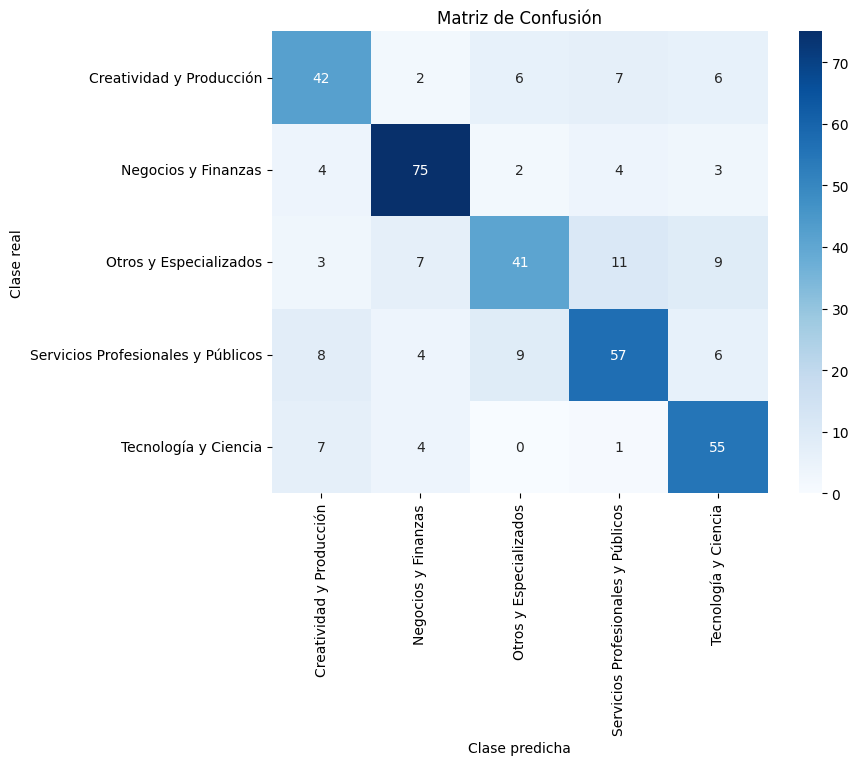


=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===


,Real,Pred
0,Otros y Especializados,Otros y Especializados
1,Servicios Profesionales y Públicos,Creatividad y Producción
2,Creatividad y Producción,Creatividad y Producción
3,Creatividad y Producción,Creatividad y Producción
4,Negocios y Finanzas,Negocios y Finanzas
5,Tecnología y Ciencia,Tecnología y Ciencia
6,Otros y Especializados,Otros y Especializados
7,Creatividad y Producción,Otros y Especializados
8,Otros y Especializados,Servicios Profesionales y Públicos
9,Tecnología y Ciencia,Tecnología y Ciencia


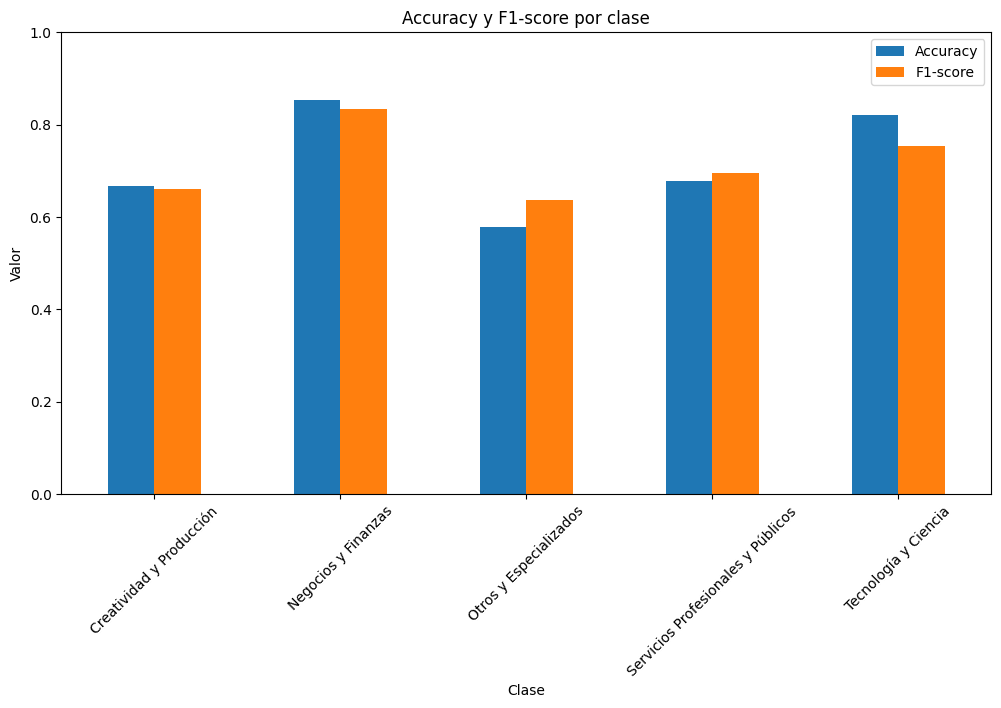

In [9]:
# Evaluación
# -------------------------
def get_predictions(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).long()
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Validación ----
val_labels, val_preds = get_predictions(val_loader)
val_acc = accuracy_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds, average='macro')
print("\n=== MÉTRICAS EN VALIDACIÓN ===")
print(f"Accuracy: {val_acc:.4f} | F1-macro: {val_f1:.4f}")

# ---- Test ----
test_labels, test_preds = get_predictions(test_loader)
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')
print("\n=== MÉTRICAS EN TEST ===")
print(f"Accuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
target_names = le.classes_
report = classification_report(test_labels, test_preds, target_names=target_names, zero_division=0, output_dict=True)
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

# ---- Resultados por clase ----
metrics_df = pd.DataFrame(report).transpose()
print("\n=== METRICAS POR CLASE ===")
display(metrics_df.iloc[:-3][['precision','recall','f1-score']])  # quitar avg/accuracy

# ---- Matriz de confusion ----
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión")
plt.show()

# ---- Comparar reales vs predichas por clase ----
comparison_df = pd.DataFrame({
    "Real": [le.classes_[i] for i in test_labels],
    "Pred": [le.classes_[i] for i in test_preds]
})
print("\n=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===")
display(comparison_df.head(10))

# ---- Gráfico de métricas por clase (Acc y F1) ----
per_class_f1 = [report[label]['f1-score'] for label in target_names]
per_class_acc = [np.mean((test_preds[test_labels==i] == i)) for i, _ in enumerate(target_names)]

metrics_plot_df = pd.DataFrame({
    "Clase": target_names,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})

metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='bar', figsize=(12,6))
plt.title("Accuracy y F1-score por clase")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

## Evaluación de rendimiento

Al entrenar el modelo BiLSTM apoyado con Word2Vec con los mejores hiperparámetros, la evaluación en el conjunto de test arrojó un desempeño moderado. La diferencia de rendimiento, tomando en cuenta las métricas de Accurary (aciertos globales) y de F1-macro (F1 promedio de clases), entre el conjunto de validación y test varía en solo 0.2 puntos, demostrando que el modelo logra generalizar bien, logrando un buen equilibrio entre la precision y la convertura.

Por clase, el grupo de _Negocios y Finanzas_ fue el que tuvo el desempeño más alto y estable, evidenciando que el modelo distingue bien esta clase. En cambio, al modelo le cuesta calcular las instancias verdaderas del grupo _Otros y especializados_.

